In [11]:
import time
import requests
from datetime import datetime, timedelta
from bs4 import BeautifulSoup
from io import StringIO
from tqdm import tqdm
from numpy import nan
import pandas as pd

url = requests.get("https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page=1")
url.text
# html = BeautifulSoup(url.text, 'html.parser')
html = BeautifulSoup(url.text)
html
table = html.find('table', {'class':'type_2'})
table

table_str = str(table)
table_io = StringIO(table_str)

tables = pd.read_html(table_io)[0]
tables = tables[tables['종목명'].notnull()]

# tables = tables.drop(['N', '토론실'], axis=1)
tables = tables.drop(['N', '토론'], axis=1)
tables.head()

kospi_box = []
for page in tqdm(range(1, 50)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page={page}")
    html = BeautifulSoup(url.text)
    
    table = html.find('table', {'class':'type_2'})
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]
    
    tables = tables.drop(['N', '토론'], axis=1)
    tables['소속'] = 'KOSPI'
    kospi_box.append(tables)
    time.sleep(1)

kosdaq_box = []
for page in tqdm(range(1, 40)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=1&page={page}")
    html = BeautifulSoup(url.text)
    
    table = html.find('table', {'class':'type_2'})
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]
    
    tables = tables.drop(['N', '토론'], axis=1)
    tables['소속'] = 'KOSDAQ'
    kosdaq_box.append(tables)
    time.sleep(1)

# stock = pd.concat(kospi_box + kosdaq_box, axis=0)
stock = pd.concat(kospi_box + kosdaq_box, ignore_index=True )
stock

sample = stock.dropna(subset='PER')
sample = sample[(sample['PER'] > 0) & (sample['PER'] < 10)]
sample = sample.sort_values(by='PER')

for i in range(len(sample)):

    data = sample.iloc[i]
    
    name = data['종목명']
    per = data['PER']

    # print(f"{i+1:3d} {name:15s} {per:6.2f}")
    print (f"{name:15s} PER : {per:6.2f}")

sample = stock.dropna(subset='ROE')
sample = sample[sample['ROE']>0]
sample = sample.sort_values("ROE", ascending=False)

for i in range(len(sample)):

    data = sample.iloc[i]
    
    name = data['종목명']
    roe = data['ROE']

    print (f"{name:15s} ROE : {roe:6.2f}")
    print (f"{name:15s} ROE : {roe:6.2f}")




100%|██████████| 39/39 [01:03<00:00,  1.62s/it]


오션인더블유          PER :   0.35
효성화학            PER :   0.41
한창              PER :   0.47
예림당             PER :   0.55
DMS             PER :   0.70
DH오토넥스          PER :   1.16
SB성보            PER :   1.35
씨엑스아이           PER :   1.42
일정실업            PER :   1.63
KC코트렐           PER :   1.66
서전기전            PER :   1.85
웅진              PER :   1.85
포니링크            PER :   1.87
우성              PER :   1.90
위메이드플레이         PER :   1.92
서한              PER :   1.93
전방              PER :   1.96
일동홀딩스           PER :   2.00
베셀              PER :   2.00
옵트론텍            PER :   2.08
한진중공업홀딩스        PER :   2.09
케이비아이동국실업       PER :   2.14
에코캡             PER :   2.15
코오롱글로벌          PER :   2.24
SG&G            PER :   2.28
유성티엔에스          PER :   2.29
솔본              PER :   2.31
대원산업            PER :   2.32
현대해상            PER :   2.36
계룡건설            PER :   2.38
DSR제강           PER :   2.38
넥센타이어1우B        PER :   2.43
우원개발            PER :   2.47
현대지에프홀딩스        PER :   2.48
서연            

In [12]:
from bs4 import BeautifulSoup
from io import StringIO
import requests
import pandas as pd
import time
from tqdm import tqdm

url = requests.get("https://finance.naver.com/sise/dividend_list.naver?&page=1")
html = BeautifulSoup(url.text)

# table = html.find('table', {'class':'type_2'})

table = html.find('table', class_='type_1 tb_ty')
table = StringIO(str(table))
table = pd.read_html(table, header = 1)[0]
table.dropna (subset = '종목명', inplace = True)
table 

total = []
for page in tqdm(range(1, 10)):
    
    url = requests.get(f"https://finance.naver.com/sise/dividend_list.naver?&page={page}")
    html = BeautifulSoup(url.text)

    table = html.find('table', class_='type_1 tb_ty')
    table = StringIO(str(table))
    table = pd.read_html(table, header = 1)[0]
    table.dropna (subset = '종목명', inplace = True)
    total.append(table)
    time.sleep(1)

total_table = pd.concat(total, ignore_index=True)

total_table.sort_values('수익률 (%)', ascending=False, inplace=True)
total_table.sort_values('수익률 (%)', ascending=False).head(10)

total_table = total_table.replace('-', 0)
total_table = total_table.dropna(subset=['배당금', '1년전', '2년전', '3년전'])

total_table['배당금'] = total_table['배당금'].astype(int)
total_table['1년전'] = total_table['1년전'].astype(int)
total_table['2년전'] = total_table['2년전'].astype(int)
total_table['3년전'] = total_table['3년전'].astype(int)

A=total_table['3년전'] < total_table['2년전']
B=total_table['2년전'] < total_table['1년전']
C=total_table['1년전'] < total_table['배당금']

# total_table [A & B & C]
total_table [A & B & C].sort_values('수익률 (%)', ascending=False).head(10)


100%|██████████| 9/9 [00:15<00:00,  1.69s/it]


,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
0,신한글로벌액티브리츠,1279.0,25.08,254,19.86,-76.31,-6.61,-8.52,0.63,126,34,0
3,NH프라임리츠,4370.0,25.05,644,14.74,21.84,9.88,7.79,0.75,540,246,233
18,이지스레지던스리츠,3845.0,25.06,300,7.80,159.24,1.18,43.68,0.49,278,262,261
19,링네트,3855.0,25.12,300,7.78,0,0,0,0,205,69,0
22,한솔로지스틱스,2745.0,25.12,200,7.29,0,0,0,0,150,100,70
30,HS애드,8280.0,25.03,550,6.64,39.29,11.77,4.63,0.51,450,400,350
32,강원랜드,17880.0,25.04,1170,6.54,51.32,12.08,7.48,0.82,930,350,0
42,KG이니시스,9770.0,25.12,600,6.14,0,0,0,0,500,420,400
50,삼성FN리츠,4860.0,25.10,280,5.76,203.79,0.74,134.57,1.02,272,195,0
64,DB손해보험,129000.0,25.03,6800,5.27,22.05,18.98,3.93,0.66,5300,4600,3500


In [13]:
import FinanceDataReader as fdr
df = fdr.StockListing('KOSPI')
# dfs = fdr.DataReader('005930', '2020-01-01')
df  

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,155400,1,5900,3.95,155000,157000,153400,16662245,2583532092200,919911733078800,5919637922,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,,764500,1,24500,3.31,766000,773000,754000,2020108,1543672247500,556557808042500,728002365,STK
2,005380,KR7005380001,현대차,KOSPI,,550000,1,1000,0.18,586000,590000,548000,3938571,2227306641000,112616771300000,204757766,STK
3,373220,KR7373220003,LG에너지솔루션,KOSPI,,415000,1,20500,5.20,397500,418000,395500,416515,171633123500,97110000000000,234000000,STK
4,005935,KR7005931001,삼성전자우,KOSPI,,112900,1,2500,2.26,114500,114900,111700,2820891,319494281900,92123539565600,815974664,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,001527,KR7001522002,동양2우B,KOSPI,,8880,3,0,0.00,8880,8880,8880,1926,17102880,2740092720,308569,STK
950,004415,KR7004411005,서울식품우,KOSPI,,1223,2,-1,-0.08,1224,1224,1203,10279,12368005,2720563500,2224500,STK
951,002787,KR7002782001,진흥기업2우B,KOSPI,,8320,0,0,0.00,0,0,0,0,0,2452802560,294808,STK
952,010600,KR7010600005,웰바이오텍,KOSPI,,15,2,-4,-21.05,15,19,14,14198505,226742888,1363851105,90923407,STK


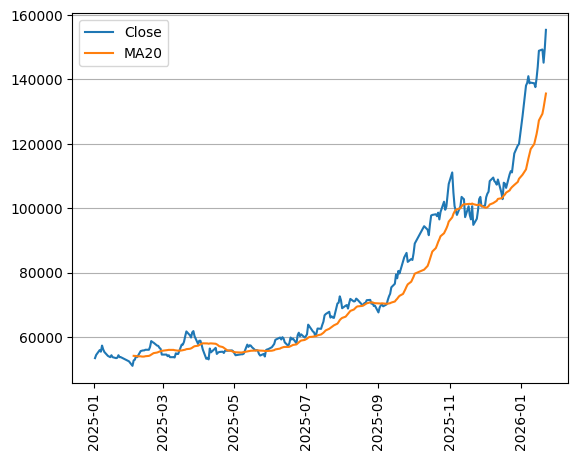

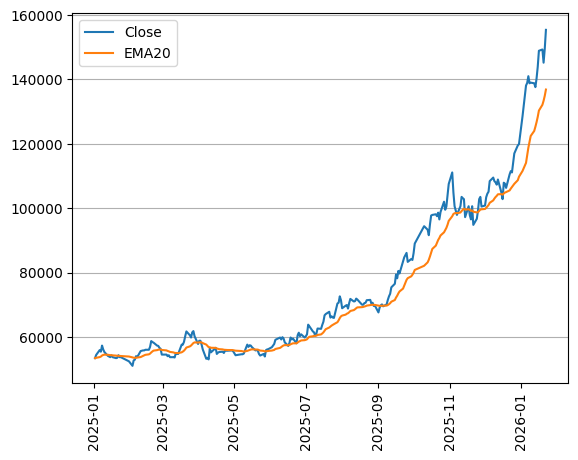

In [14]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

dfs = fdr.DataReader("005930")
dfs = dfs[dfs.index.year >= 2025]

dfs['MA20'] = dfs['Close'].rolling(window = 20).mean()

plt.plot(dfs['Close'])
plt.plot(dfs['MA20'])
plt.legend(['Close', 'MA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()


dfe = fdr.DataReader("005930")
dfe = dfe[dfe.index.year >= 2025]

# 종가를 기반으로 하는 20일 지수 이동 평균(EMA) 계산
dfe['EMA20'] = dfe['Close'].ewm(span=20, adjust=False).mean()

plt.plot(dfe['Close'])
plt.plot(dfe['EMA20'])
plt.legend(['Close', 'EMA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()

In [ ]:
### EMA를 활용해서 추천 종목 발굴하기

import FinanceDataReader as fdr

stocks = fdr.StockListing('KOSPI') #소스코드에 없어서 임의로 추가함

nameArr = []
for i in range(len(stocks)):

    stock = stocks.iloc[i]
    code = stock['Code']
    name = stock['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    
    today_data = df.iloc[-1]
    
    if today_data['Close'] < today_data['EMA20']:
        
        nameArr.append(name)
        # print(name)

print (len(stocks), " 건 중에서 ")
print (len(nameArr), " 건 있습니다.")
print (nameArr)

954  중에서 
454  건이 있습니다.
['삼성바이오로직스', 'NAVER', 'HD한국조선해양', '카카오', '삼성에피스홀딩스', '삼성에스디에스', '크래프톤', '카카오뱅크', 'SK바이오팜', '유한양행', 'HD현대마린솔루션', '이수페타시스', '코웨이', '한미약품', '삼성E&A', 'JB금융지주', 'SK바이오사이언스', '강원랜드', 'HD현대마린엔진', '대한조선', 'HD현대인프라코어', '동서', 'F&F', '농심', '현대해상', '한올바이오파마', '제일기획', 'iM금융지주', '코리안리', 'HJ중공업', '현대백화점', '시프트업', '대웅제약', '동원산업', '녹십자', '씨에스윈드', 'SK리츠', 'SNT다이내믹스', 'GS건설', '아시아나항공', '미래에셋생명', 'HDC현대산업개발', '엠앤씨솔루션', '대웅', '하이트진로', '한일시멘트', 'SK오션플랜트', 'SK케미칼', '일동제약', '롯데렌탈', '더블유게임즈', '세진중공업', '한샘', 'HDC', '에스디바이오센서', 'NHN', '쿠쿠홀딩스', '명인제약', 'LX세미콘', 'GS피앤엘', '경동나비엔', 'GKL', '케이씨텍', '파미셀', 'DL', 'TKG휴켐스', '케이카', '솔루엠', 'KG모빌리티', '하나투어', '녹십자홀딩스', '미원상사', '동아쏘시오홀딩스', '미원에스씨', '아이에스동서', 'SK이터닉스', '프레스티지바이오파마', '신풍제약', '금양', 'HD현대에너지솔루션', '카프로', '아세아', '코오롱', '한국쉘석유', '제이알글로벌리츠', '비에이치', '바이오노트', '덴티움', '롯데손해보험', '쿠쿠홈시스', 'LF', '일진하이솔루스', '퍼시스', '자화전자', '신대양제지', '풀무원', '현대그린푸드', '한일홀딩스', '삼양사', '태영건설', '디아이씨', '동아에스티', '신도리코', '삼양홀딩스', '제주은행', '아세아시멘트', 'SPC삼립', '코람코라이프인프라리츠', '천일고

In [26]:
### RSI (Relative Strength Index, 상대강도지수)는 기술적 분석에서 널리 사용되는 모멘텀 지표 중 하나입니다. 
### 1978년 웰스 와일더(Welles Wilder)에 의해 개발된 이 지표는 주식이 과매수 또는 과매도 상태인지를 평가하며, 
### 시장의 추세 전환 시점을 예측하는 데 도움을 줍니다.

import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

def calculate_rsi(data, window=14):
    """
    데이터프레임의 'Close' 열을 사용하여 RSI 값을 계산합니다.
    
    :param data: 주식 데이터가 포함된 데이터프레임
    :param window: RSI를 계산하기 위한 기간 (기본값: 14일)
    :return: RSI가 포함된 데이터프레임
    """
    
    close = data['Close']   # 종가 데이터
    delta = close.diff()    # 종가의 변화량 계산
    
    # print ("delta : ",delta)    # 변화량 신경망에서도 기울기/가중치 델타 사용 했었음. *** debug 용 프린트 여서 주석처리
    
    # 상승과 하락을 분리
    gain = delta.where(delta > 0, 0)    # 상승분 양수인 경우 해당값 반환
    loss = -delta.where(delta < 0, 0)   # 하락분 음수인 경우 양수로 변환
    
    # 이동 평균 계산
    avg_gain = gain.rolling(window=window, min_periods=1).mean() # 주어진 기간의 평균 상승분
    avg_loss = loss.rolling(window=window, min_periods=1).mean() # 주어진 기간의 평균 하락분
    
    # RS 및 RSI 계산
    rs = avg_gain / avg_loss        # 상대 강도 (Relative Strength)
    rsi = 100 - (100 / (1 + rs))    # RSI 계산 (Relative Strength Index)
    
    return rsi

# RSI 계산 및 시각화
warnings.filterwarnings("ignore")   # 경고 무시
df=fdr.DataReader("005930")         # 삼성전자 주식 데이터 가져오기
df['RSI']=calculate_rsi(df)         # RSI 계산 및 추가
df = df.dropna()                    # 결측값 제거
df                                  # 데이터 프레임 출력

,Open,High,Low,Close,Volume,Change,RSI
Date,,,,,,,
2013-11-05,30040,30040,29440,29700,160186,-0.009340,0.000000
2013-11-06,29959,29959,28979,29020,244368,-0.022896,0.000000
2013-11-07,29020,29080,28500,28740,260136,-0.009649,0.000000
2013-11-08,28220,28560,28140,28200,273627,-0.018789,0.000000
2013-11-11,28500,28680,28180,28560,171277,0.012766,16.822430
...,...,...,...,...,...,...,...
2026-01-16,145300,149500,144300,148900,30000219,0.034746,92.000000
2026-01-19,147200,150600,146600,149300,22762497,0.002686,90.886076
2026-01-20,148500,149300,143900,145200,24059218,-0.027461,81.265207


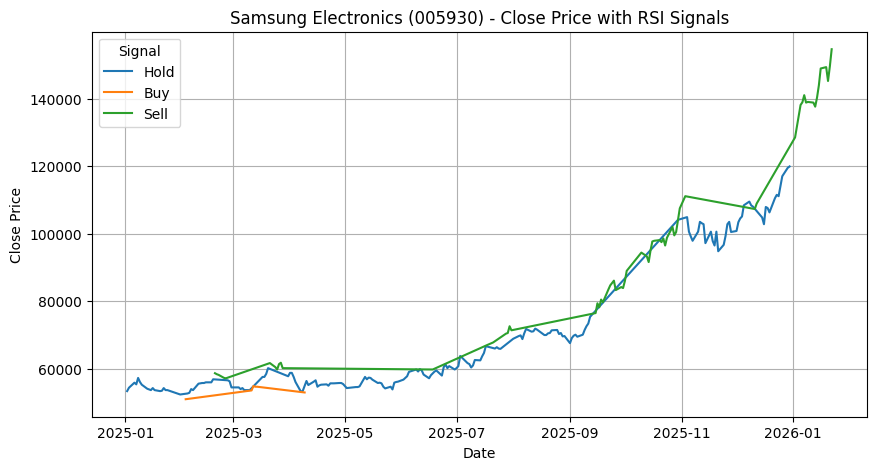

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import FinanceDataReader as fdr
import warnings

df = fdr.DataReader("005930")
df['RSI'] = calculate_rsi(df)   # RSI 계산 및 추가 - 위헤서 선언한 calculate_rsi 함수 사용
df = df.dropna()

# 새로운 열 'Signal' 추가하는 함수 정의
def get_signal(rsi):
    if rsi <= 30:
        return 'Buy'
    elif rsi >= 70:
        return 'Sell'
    else:
        return 'Hold'

# 데이터프레임에 새로운 열 추가
# RSI 값에 따라 'Buy', 'Sell', 'Hold' 신호 할당, apply(get_signal) 함수 사용
df['Signal'] = df['RSI'].apply(get_signal)  

plt.figure(figsize = (10, 5))   #그래프 크기 설정

df2 = df[df.index.year >= 2025]

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal') #종가를 기준으로 신호에 따라 선 그래프 그리기
plt.title("Samsung Electronics (005930) - Close Price with RSI Signals")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid()
plt.show()



In [32]:
sGrp = 'KOSDAQ'
stocks = fdr.StockListing(sGrp) [['Code', 'Name']] 
lLen = len(stocks)-(len(stocks)-50)

print(f"{sGrp} 에서 총 {len(stocks)} 건 중 {lLen} 건 확인")

for i in range (lLen):
    stock = stocks.iloc[i]      # stocks dataframe 의 i번째 행 
    code = stock['Code']
    name = stock['Name']
    df = fdr.DataReader("Naver: " + code)
    df['RSI'] = calculate_rsi(df)
    today_data = df.iloc[-1]['RSI']     # dataframe 의 마지막 행

    if today_data > 70:
        print(f"{name} : 매도 신호 !")
    elif today_data < 30:
        print(f"{name} : 매수 신호 !")

KOSDAQ 에서 총 1827 건 중 50 건 확인
에코프로비엠 : 매도 신호 !
삼천당제약 : 매도 신호 !
현대무벡스 : 매도 신호 !
실리콘투 : 매도 신호 !
휴림로봇 : 매도 신호 !
솔브레인 : 매도 신호 !
에스엠 : 매수 신호 !
JYP Ent. : 매수 신호 !
씨어스테크놀로지 : 매도 신호 !
비에이치아이 : 매도 신호 !


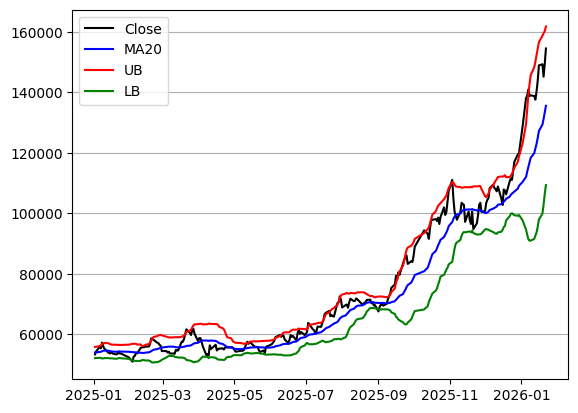

In [33]:
# John Bollinger
# 상대적 과매수 과매도 상태를 식별, 추세의 변화나 가격의 이동을 예측하는 데 유용 

import pandas as pd
import numpy as np
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

df['MA20'] = df['Close'].rolling(window = 20).mean()    #평균
df['STD20'] = df['Close'].rolling(window = 20).std()    #표준편차

df['UB'] = df['MA20'] + 2 * df['STD20']
df['LB'] = df['MA20'] - 2 * df['STD20']

df = df[df.index.year >= 2025]

plt.plot(df['Close'], color = 'black')
plt.plot(df['MA20'], color = 'blue')
plt.plot(df['UB'], color = 'red')
plt.plot(df['LB'], color = 'green')

plt.grid(axis = 'y')
plt.legend(['Close', 'MA20', 'UB', 'LB'])
# plt.xticks(rotation = 90)   # x축의 눈금 label 을 90도 회전시킨다
plt.show()


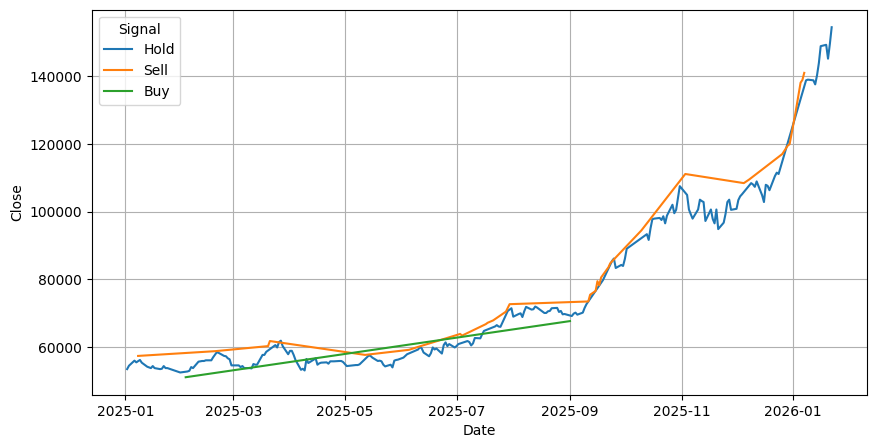

In [34]:
# 볼린저 밴드 신호 생성 함수 정의
def get_bollinger_signal(row):
    if row['Close'] < row['LB']:
        return 'Buy'
    elif row['Close'] > row['UB']:
        return 'Sell'
    else:
        return 'Hold'

# 주식 데이터 가져오기
name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

# 볼린저 밴드 계산하여 데이터 프레임에 추가
df['MA20'] = df['Close'].rolling(window = 20).mean() # 20일 이동 평균
df['STD20'] = df['Close'].rolling(window = 20).std() # 20일 표준 편차
df['UB'] = df['MA20'] + 2 * df['STD20']     # 볼린저 상한 밴드 - 일정 표준 편자 보통 2 표준 편차
df['LB'] = df['MA20'] - 2 * df['STD20']     # 볼린저 하한 밴드 - 일정 표준 편자 보통 2 표준 편차
# 종가가 상한 보다 높을때 팔고 하한보다 낮을때 산다

# 2025 이후로 필터링 
df2 = df[df.index.year >= 2025]

# 각 행에 대하여 볼린저 밴드 신호를 계산하여 Signal 열에 추가
df2['Signal'] = df2.apply(get_bollinger_signal, axis=1)

plt.figure(figsize = (10, 5))

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal')

plt.grid()
plt.show()

In [4]:
import FinanceDataReader as fdr

stocks = fdr.StockListing("KRX")

#stocks.dropna()
stocks.dropna(subset='Code')

sCnt = len(stocks)
aCnt = sCnt - (sCnt - 50)    # ==========> 49 개 이상 이면 오류 발생
print (f"{sCnt} 개의 주식중 {aCnt} 개를 검사")

for i in range(aCnt):

    data = stocks.iloc[i]

    code = data['Code']
    name = data['Name']
    print ("*** code :: ", i, "***", code)
    print ("*** name :: ", i, "***", name)

    df = fdr.DataReader(code)

    df['MA20'] = df['Close'].rolling(window = 20).mean()
    df['STD20'] = df['Close'].rolling(window = 20).std()
    
    df['UB'] = df['MA20'] + 2 * df['STD20']
    df['LB'] = df['MA20'] - 2 * df['STD20']

    today = df.iloc[-1]

    if today['Close'] < today['LB']:
        print(f"{name} @@@ 매수 신호입니다!")
    elif today['Close'] > today['UB']:
        print(f"{name} *** 매도 신호입니다!")

2894 개의 주식중 50 개를 검사
*** code ::  0 *** 005930
*** name ::  0 *** 삼성전자
*** code ::  1 *** 000660
*** name ::  1 *** SK하이닉스
*** code ::  2 *** 005380
*** name ::  2 *** 현대차
*** code ::  3 *** 373220
*** name ::  3 *** LG에너지솔루션
LG에너지솔루션 *** 매도 신호입니다!
*** code ::  4 *** 005935
*** name ::  4 *** 삼성전자우
*** code ::  5 *** 207940
*** name ::  5 *** 삼성바이오로직스
*** code ::  6 *** 012450
*** name ::  6 *** 한화에어로스페이스
*** code ::  7 *** 329180
*** name ::  7 *** HD현대중공업
*** code ::  8 *** 000270
*** name ::  8 *** 기아
*** code ::  9 *** 402340
*** name ::  9 *** SK스퀘어
*** code ::  10 *** 034020
*** name ::  10 *** 두산에너빌리티
*** code ::  11 *** 105560
*** name ::  11 *** KB금융
*** code ::  12 *** 028260
*** name ::  12 *** 삼성물산
*** code ::  13 *** 068270
*** name ::  13 *** 셀트리온
*** code ::  14 *** 015760
*** name ::  14 *** 한국전력
한국전력 *** 매도 신호입니다!
*** code ::  15 *** 042660
*** name ::  15 *** 한화오션
*** code ::  16 *** 012330
*** name ::  16 *** 현대모비스
*** code ::  17 *** 055550
*** name ::  17 *** 신한지주


## 포트폴리오 이론
포트폴리오 이론은 투자 포트폴리오를 구성하고 관리하는 방법에 관한 경제학적 이론으로, 투자 위험을 최소화하고 기대 수익을 최대화하는 방법을 모색합니다. 이 이론은 1952년 해리 마코위츠(Harry Markowitz)에 의해 "포트폴리오 선택(Portfolio Selection)" 논문에서 처음 제시되었으며, 이는 현대 포트폴리오 이론(Modern Portfolio Theory, MPT)의 기초가 되었습니다.

### 포트폴리오 이론의 주요 개념
* 분산 투자: 투자 리스크를 줄이기 위해 여러 자산에 걸쳐 투자함으로써 한 자산의 부진이 전체 포트폴리오에 미치는 영향을 최소화합니다.

* 효율적 투자선(Efficient Frontier): 주어진 위험 수준에서 최대의 기대 수익을 제공하는 자산 조합을 나타내는 곡선입니다. 이 곡선 위의 포트폴리오는 주어진 위험에 대해 최대의 수익을 제공하므로 '효율적'이라고 합니다.

* 기대 수익률과 위험: 포트폴리오의 기대 수익률은 포함된 각 자산의 기대 수익률과 그 비중에 따라 계산되며, 위험(변동성)은 자산 간 상관관계에 따라 다르게 나타납니다. 낮은 상관관계의 자산 조합은 포트폴리오의 전체 위험을 줄일 수 있습니다.

* 시장 포트폴리오: 모든 투자 가능 자산을 포함하며, 모든 효율적 포트폴리오는 이 시장 포트폴리오와 무위험 자산의 조합으로 표현될 수 있습니다.

### 포트폴리오 이론의 중요성
포트폴리오 이론은 개별 투자보다는 전체 포트폴리오의 성과에 초점을 맞춥니다. 이 이론은 투자자가 자신의 위험 선호도에 맞는 자산 조합을 선택할 수 있도록 도와주며, 다음과 같은 중요한 이점을 제공합니다.

* 위험 관리: 서로 다른 자산 간의 상관관계를 고려하여 위험을 분산시키고, 전체적인 포트폴리오의 변동성을 줄입니다.
* 투자 결정 지원: 투자자는 자신의 위험 감수 능력과 기대 수익률에 기반하여 합리적인 투자 결정을 내릴 수 있습니다.
* 자산 할당: 자산 간의 비중을 조절함으로써 기대 수익을 최적화하고, 경제적 환경 변화에 따라 포트폴리오를 조정할 수 있습니다.

포트폴리오 이론은 투자자에게 체계적이고 과학적인 접근 방식을 제공하여, 감정에 휘둘리지 않고 투자 결정을 내릴 수 있는 토대를 마련해 줍니다. 이 이론을 통해 투자자는 경제적 환경의 변화에도 견딜 수 있는 견고한 투자 전략을 수립할 수 있습니다.

In [58]:
import numpy as np

# 수익률 데이터 :: 5% 7% -2% 10% 4%
returns = np.array([0.05, 0.07, -0.02, 0.10, 0.04])
print ("returns ::", returns)
# 평균 수익률 계산
mean_return = np.mean(returns)
print ("mean_return ::", mean_return)
# 분산 계산 :: 각 수익률에서 평균을 뺀 값을 제곱한 후 평균을 계산
variance = np.mean((returns - mean_return) ** 2)
print ("returns - mean_return ::", returns - mean_return)
print ("returns - mean_return ** 2 ::", (returns - mean_return)**2)
print ("variance :: ", variance)

# 표준편차 계산
std_dev = np.sqrt(variance)
print ("std_dev :: ", std_dev)

returns :: [ 0.05  0.07 -0.02  0.1   0.04]
mean_return :: 0.048
returns - mean_return :: [ 0.002  0.022 -0.068  0.052 -0.008]
returns - mean_return ** 2 :: [4.000e-06 4.840e-04 4.624e-03 2.704e-03 6.400e-05]
variance ::  0.0015760000000000004
std_dev ::  0.03969886648255842


returns ::  [0.12 0.18]
risks ::  [0.1 0.2]
cov_matrix ::  [[0.01 0.01]
 [0.01 0.04]]
portfolio_return ::  0.18
portfolio_risk ::  0.2
portfolio_return ::  0.1793939393939394
portfolio_risk ::  0.1984867761491713
portfolio_return ::  0.17878787878787877
portfolio_risk ::  0.19697746682421846
portfolio_return ::  0.17818181818181816
portfolio_risk ::  0.19547216270145626
portfolio_return ::  0.17757575757575755
portfolio_risk ::  0.19397095702755793
portfolio_return ::  0.17696969696969697
portfolio_risk ::  0.19247394570043114
portfolio_return ::  0.17636363636363636
portfolio_risk ::  0.19098122735259068
portfolio_return ::  0.17575757575757575
portfolio_risk ::  0.18949290343708125
portfolio_return ::  0.17515151515151517
portfolio_risk ::  0.18800907831599972
portfolio_return ::  0.17454545454545453
portfolio_risk ::  0.18652985935166538
portfolio_return ::  0.17393939393939392
portfolio_risk ::  0.18505535700048262
portfolio_return ::  0.1733333333333333
portfolio_risk ::  0.183585

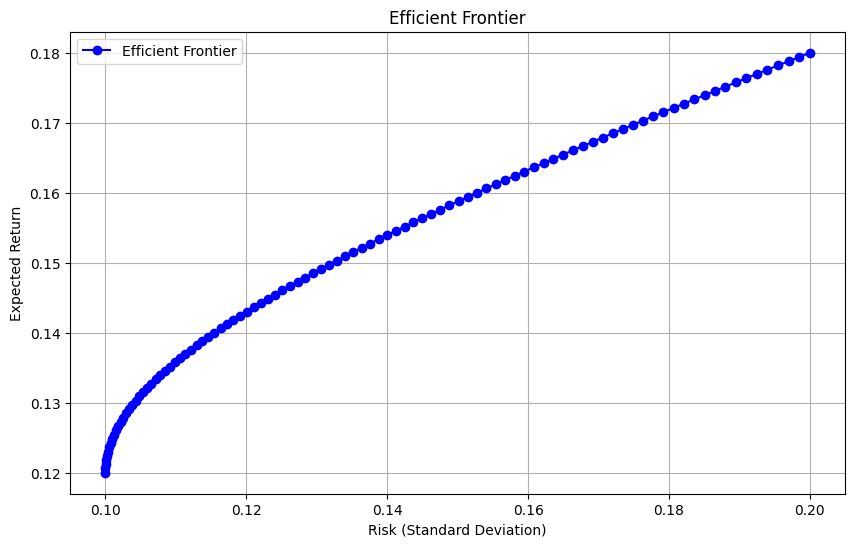

In [59]:
# 효율적 투자선 
# 특정 위험 수준 에서 최대의 이익 
# 특정 이익 수준에서 최소의 위험 있는 최적의 포트폴리오 조합

import numpy as np
import matplotlib.pyplot as plt

# 예시 자산의 수익률과 표준편차 (리스크)
returns = np.array([0.12, 0.18])  # 자산의 기대 수익률 expected return
risks = np.array([0.1, 0.2])      # 자산의 표준편차 (리스크)
correlation = 0.5                 # 두 자산의 상관관계
print ("returns :: ", returns)
print ("risks :: ", risks)

# 공분산 행렬 계산. *****
cov_matrix = np.array([[risks[0]**2, risks[0]*risks[1]*correlation],
                       [risks[0]*risks[1]*correlation, risks[1]**2]])
print ("cov_matrix :: ", cov_matrix)

# 포트폴리오 수익률과 리스크 계산
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.sum(weights * returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    print ("portfolio_return :: ", portfolio_return)
    print ("portfolio_risk :: ", portfolio_risk)
    return portfolio_return, portfolio_risk

# 다양한 포트폴리오의 수익률과 리스크 계산
weights_list = []
portfolio_returns = []
portfolio_risks = []

for w1 in np.linspace(0, 1, 100):
    w2 = 1 - w1
    weights = np.array([w1, w2])    # 가중치를 넘파이 배열로 정의 *****
    ret, risk = portfolio_performance(weights, returns, cov_matrix)
    weights_list.append(weights)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

# 효율적 투자선 그리기
plt.figure(figsize=(10, 6))
plt.plot(portfolio_risks, portfolio_returns, 'b-o', label='Efficient Frontier')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
# 최고의 투자 비율 찾기

import FinanceDataReader as fdr

stocks = fdr.DataReader(['AAPL', 'TSLA', 'META'])
stocks = stocks.dropna()
print ("***** stocks")
print (stocks)

daily_ret = stocks.pct_change()     # 일간 수익율 계산
annual_ret = stocks.mean()          # 평균 수익율 계산

daily_cov = daily_ret.cov()         # 일간 수익율 공분산
annual_cov = daily_cov * 252        # 년간 수익율 공분산

print ("*** daily_ret")
print (daily_ret)
print ("*** annual_ret")
print (annual_ret)
print ("*** daily_cov")
print (daily_cov)
print ("*** annual_cov")
print (annual_cov)

# 초기화 :: 수익율, 리스크, 가중치
port_ret = []
port_risk = []
port_weights = []

***** stocks
                  AAPL        TSLA        META
2012-05-18   15.906647    1.837333   37.964806
2012-05-21   16.833372    1.918000   33.793938
2012-05-22   16.704111    2.053333   30.784958
2012-05-23   17.111692    2.068000   31.778021
2012-05-24   16.954538    2.018667   32.800877
...                ...         ...         ...
2026-01-14  259.959991  439.200012  615.520020
2026-01-15  258.209991  438.570007  620.799988
2026-01-16  255.529999  437.500000  620.250000
2026-01-20  246.699997  419.250000  604.119995
2026-01-21  247.649994  431.440002  612.960022

[3438 rows x 3 columns]
*** daily_ret
                AAPL      TSLA      META
2012-05-18       NaN       NaN       NaN
2012-05-21  0.058260  0.043904 -0.109861
2012-05-22 -0.007679  0.070559 -0.089039
2012-05-23  0.024400  0.007143  0.032258
2012-05-24 -0.009184 -0.023855  0.032188
...              ...       ...       ...
2026-01-14 -0.004175 -0.017889 -0.024672
2026-01-15 -0.006732 -0.001434  0.008578
2026-01-16 -0.0

          Returns      Risk      AAPL      TSLA      META
0      127.671269  0.325775  0.404758  0.376729  0.218513
1      130.096117  0.307470  0.443817  0.306315  0.249869
2      169.553632  0.326790  0.197254  0.240539  0.562207
3      103.721219  0.383077  0.445856  0.549568  0.004575
4      147.028147  0.333688  0.264382  0.368236  0.367382
...           ...       ...       ...       ...       ...
99995  124.167995  0.284289  0.573246  0.203086  0.223668
99996  112.696568  0.330169  0.501976  0.397230  0.100793
99997  128.392770  0.338875  0.364819  0.418906  0.216276
99998  148.583300  0.411505  0.067822  0.594401  0.337777
99999  133.915780  0.285744  0.507929  0.192229  0.299841

[100000 rows x 5 columns]


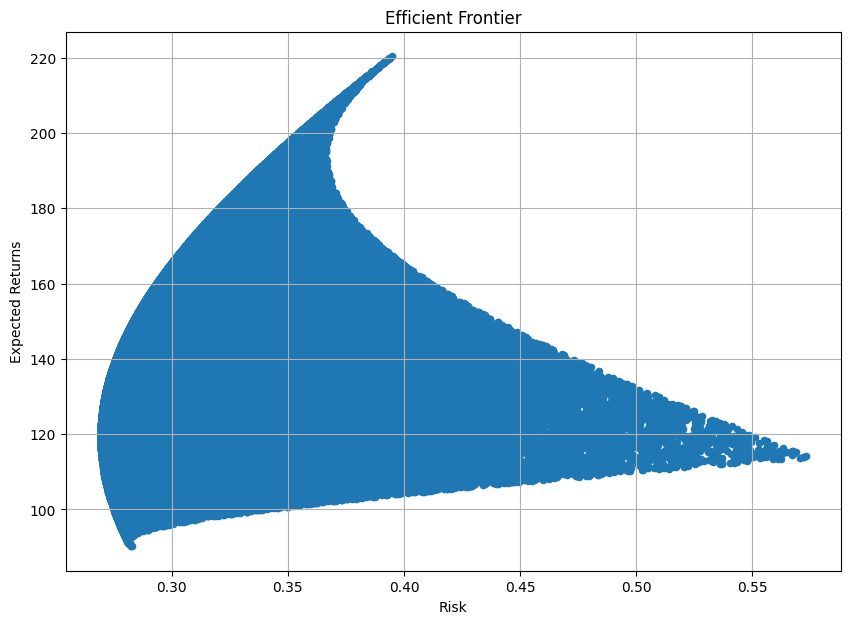

In [68]:
# Monte Carlo Simulation
# 포트폴리오 이론에서 최적의 투자비율을 구하는것에 적용

import pandas as pd
import matplotlib.pyplot as plt

for i in range(100000):

    # 랜덤 가중치 생성 
    weights = np.random.random(3)
    weights /= np.sum(weights)

    # 포트폴리오 수익율 및 리스크 계산
    returns = np.dot(weights, annual_ret)       # 예상 수익율 :: 가중치와 연간수익율의 내적
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))  # 리스크 (표준편차) :: 가중치 와 연간공분산 행렬

    # 성과 저장
    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)

# 포트롤리오 데이터 프레임 생성
portfolio = {'Returns' : port_ret, "Risk" : port_risk}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

# 테이터 프레임 생성 및 정렬
df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk'] + [s for s in stocks.columns]]
print (df)

# ===============
# 결과 시각화
# ===============

# 산점도 그리기
df.plot.scatter(x = 'Risk', y = 'Returns', figsize = (10, 7), grid = True)

plt.title("Efficient Frontier")
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()

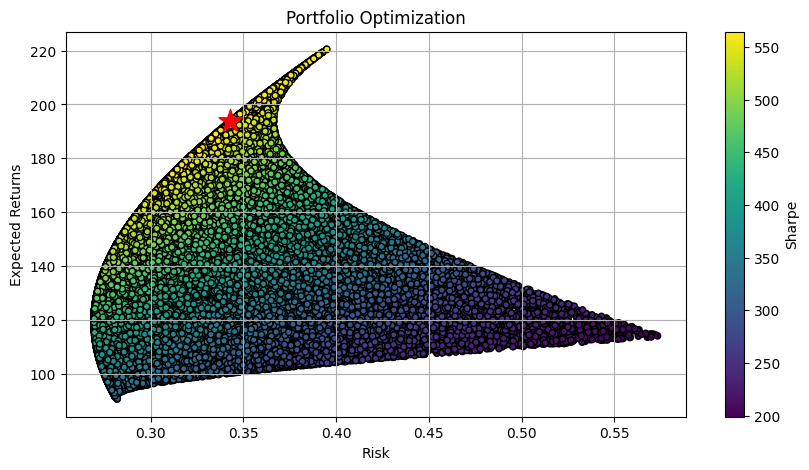

In [69]:
# 샤프 지수 Sharpe Ratio
# 포트폴리오의 상과를 평가하는데 사용 :: 위험대비 수익율을 측정, 포트폴리오의 초과수익율을 단위 리스크당 얼마나 얻었나

daily_ret = stocks.pct_change()
annual_ret = stocks.mean()

daily_cov = daily_ret.cov()
annual_cov = daily_cov * 252

port_ret = []
port_risk = []
port_weights = []
sharpe_ratio = []

for i in range(100000):

    weights = np.random.random(3)
    weights /= np.sum(weights)

    returns = np.dot(weights, annual_ret)
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))

    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)
    sharpe_ratio.append(returns / risk)

portfolio = {'Returns' : port_ret, "Risk" : port_risk, 'Sharpe' : sharpe_ratio}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk', 'Sharpe'] + [s for s in stocks.columns]]

max_sharpe = df.loc[df['Sharpe'] == df['Sharpe'].max()]
max_sharpe

# 시각화
df.plot.scatter(x = 'Risk', y = 'Returns', c = 'Sharpe', cmap = 'viridis', edgecolors = 'k', figsize = (10, 5), grid = True)
plt.scatter(x = max_sharpe['Risk'], y = max_sharpe['Returns'], c = 'r', marker = '*', s = 300)
plt.title('Portfolio Optimization')
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()


In [70]:
### 인공지능 머신러닝 딥러닝 - 신경망
### 머신리닝 - 지도, 비지도, 강화

# 미래 주식 가격 예측하기

import FinanceDataReader as fdr
import numpy as np

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)

# df 값을 넘파이 배열에 저장    
x = np.array(x) 
y = np.array(y)

print(x)
print(y)


[[ 3.00400000e+04  3.00400000e+04  2.94400000e+04  2.97000000e+04
   1.60186000e+05 -9.33955971e-03]
 [ 2.99590000e+04  2.99590000e+04  2.89790000e+04  2.90200000e+04
   2.44368000e+05 -2.28956229e-02]
 [ 2.90200000e+04  2.90800000e+04  2.85000000e+04  2.87400000e+04
   2.60136000e+05 -9.64851826e-03]
 ...
 [ 1.47200000e+05  1.50600000e+05  1.46600000e+05  1.49300000e+05
   2.27624970e+07  2.68636669e-03]
 [ 1.48500000e+05  1.49300000e+05  1.43900000e+05  1.45200000e+05
   2.40592180e+07 -2.74614869e-02]
 [ 1.41900000e+05  1.49800000e+05  1.41800000e+05  1.49500000e+05
   3.17036100e+07  2.96143251e-02]]
[ 29020.  28740.  28200. ... 145200. 149500. 155300.]


In [ ]:
"""
[[K 최근접 이웃 모델]]을 활용한 다음날 주식 가격 예측
K-최근접 이웃(K-Nearest Neighbors, KNN) 모델은 
분류와 회귀 분석에 모두 사용할 수 있는 단순하고 직관적인 기계 학습 알고리즘입니다. 
KNN은 새로운 데이터 포인트의 클래스나 값을 예측할 때, 
훈련 데이터에서 가장 가까운 K개의 이웃을 참고하여 결정을 내립니다. 
이 알고리즘은 주로 패턴 인식, 데이터 마이닝, 통계 분석 등 다양한 분야에서 사용됩니다.
"""

# k 분류 모델 적용 : 가장 가까운 값들의 갯수
# k 회귀 모델 적용 : 가장 가까운 값들의 평균

# KNN 최근접 회귀 모델 가져오기
from sklearn.neighbors import KNeighborsRegressor
# 데이터를 학습/테스트 세트로 나눠주는 함수 가져오기
from sklearn.model_selection import train_test_split

# 학습/테스트 데이터 만들기 위한 주식 데이터 가져오는 라이브러리
import FinanceDataReader as fdr
# 데이터 처리를 위한 라이브러리 :: pandas
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)

# 데이터 분할
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 생성, 학습 ==> train data 를 사용
model = KNeighborsRegressor()   
model.fit(train_x, train_y)

# 모델 평가 ==> test data 를 사용
# ***** 테스트 데이터를 사용하여 모델의 성능을 평가하고, 결정 계수를 score 에 저장
score = model.score(test_x, test_y)

# 예측 위한 df 데이터 프레임 마지막 행 데이터를 numpy 배열로 변환
today_data = df.iloc[-1].to_numpy()

# 모델 예측 
pred = model.predict([today_data])[0]

# 예측된 pred 를 포맷팅하여 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2026-01-30의 삼성전자의 주식 예측 가격은 55,870원입니다. 오차 범위는 26.66% 입니다.


In [ ]:
"""
[[결정트리 모델]]을 활용한 다음날 주식 가격 예측
결정 트리(Decision Tree) 모델은 분류와 회귀 분석에 모두 사용할 수 있는 비모수적 기계 학습 알고리즘입니다. 
결정 트리는 데이터의 특성과 대상 값을 기준으로 데이터를 분할하여 의사 결정 규칙을 학습하는 방법입니다. 
트리 구조는 루트 노드, 내부 노드, 리프 노드로 구성되며, 각 내부 노드는 데이터의 특성을 기준으로 분할하고, 
리프 노드는 최종 예측 결과를 나타냅니다.

*** 가지치기 pruning 로 overfitting 보완, 앙상블 기법 random forest 로 안정성을 확보할 수 있다 
"""

# 트리의 결정트리 모델 import 
from sklearn.tree import DecisionTreeRegressor
# data 분함 함수 
from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 학습
model = DecisionTreeRegressor()
model.fit(train_x, train_y)     # fitting 한다. over/under...
# 모델 평가
score = model.score(test_x, test_y)
# 예측일 데이터 생성
today_data = df.iloc[-1].to_numpy()
# 모델 예측
pred = model.predict([today_data])[0]
# 결과 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2026-01-30의 삼성전자의 주식 예측 가격은 159,500원입니다. 오차 범위는 0.61% 입니다.


In [ ]:
"""
[[랜덤포레스트 모델]]을 활용한 다음날 주식 가격 예측
랜덤 포레스트(Random Forest) 모델은 다수의 결정 트리를 사용하여 분류나 회귀 작업을 수행하는 
앙상블 학습 방법 중 하나입니다. 
이는 개별 결정 트리의 약점을 보완하고, 모델의 성능과 안정성을 향상시키기 위해 개발되었습니다. 
랜덤 포레스트는 배깅(Bagging) 기법과 특성 무작위성(feature randomness)을 결합하여 다수의 결정 트리를 생성하고, 
이들의 예측을 결합하여 최종 결과를 도출합니다.

* 부트 스트랩 샘플링
    원본 데이터에서 중복을 허용하여 여러 개의 샘플 데이터를 생성
* 랜덤 피처 선택
    각 [루프, 인터널, 리프 노드 ... ???] 를 분할할때 전체 피처 (what ?) 중 무작위로 선택된 일부 피처만을 고려
* 결정 트리 : 부트 스트랩과 랜덤 피처를 사용하여 다수의 결정 트리를 생성
* 앙상블 예측 :
    분류 문제 - 각 트리의 예측 결과를 투표하여 가장 많이 선택된 클래스가 최종 예측
    회귀 문제 - 각 트리의 예측 결과를 평균한 것이 최종 예측
"""
# 앙상블의 랜덤포레스트 모델 임포트
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 초기화
model = RandomForestRegressor()
# 모델 헉숩
model.fit(train_x, train_y)
# 모델 평가  ==> 모델 라이브러리 에서 알아서 스코어 생성 ???
score = model.score(test_x, test_y)

# 예측
today_data = df.iloc[-1].to_numpy()
pred = model.predict([today_data])[0]

# 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2026-01-30의 삼성전자의 주식 예측 가격은 157,521원입니다. 오차 범위는 0.34% 입니다.


In [1]:
"""
[[XGBoost 모델]]을 활용한 다음날 주식 가격 예측
XGBoost(Extreme Gradient Boosting) 모델은 결정 트리 알고리즘을 기반으로 한 강력한 앙상블 학습 기법입니다. 이는 주로 분류와 회귀 분석에 사용되며, 높은 예측 성능과 효율성 덕분에 다양한 데이터 과학 대회에서 널리 사용됩니다. XGBoost는 그레디언트 부스팅(Gradient Boosting) 알고리즘의 확장판으로, 성능을 최적화하고 실행 속도를 높이기 위해 여러 가지 개선 사항을 도입했습니다.
"""
# Decision Tree : 여러개의 결정 트리를 사용하여 각각 약한 학습자로 작동하며 이들이 모여 강력한 예측 모델을 형성 
# 오차 Residuals : 현재 모델의 예측과 실젯값 사이 차이를 계산하여 새로운 트리를 학습
# 학습율 Learning Rate : 각 트리의 기여도를 조절하여 모델이 천천히 학습되도록 한다.
# 규제 Regulations : L1, L2 규제, 모델의 복잡성을 제어하여 오버피팅 방지
# Boosting Stage : 여러 트리를 순차적으로 추가하여 모델 성능을 점진적으로 향상

# xgboost 에서 xgbregressor 를 import - 결정 트리 모델을 업그레이드한 모델
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 초기화
model = XGBRegressor()
# 학습
model.fit(train_x, train_y)
# 평가
score = model.score(test_x, test_y)

# 예측/추론 ??
today_data = df.iloc[-1].to_numpy()
pred = model.predict([today_data])[0]

# 출력
date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2026-01-30의 삼성전자의 주식 예측 가격은 139,786원입니다. 오차 범위는 0.54% 입니다.


In [2]:
"""
### 국내 주식 미래 주식 가격 예측하기
랜덤 포레스트 모델을 사용해서 우리나라 국내 모든 주식 종목의 다음날 가격을 예측하는 프로그램.
"""

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

# 상장 주식 목록을 가져오기
stocks = fdr.StockListing("KOSPI")

for s in range(len(stocks)-(len(stocks)-30)):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    # 종목 코드를 사용하여 주식 데이터를 가져오고, 결측값을 제거 
    # 아... naver 주식 자료를 가져오는 것이라서 코드에 naver 를 붙여서 코드 값 생성 ???
    df = fdr.DataReader("NAVER:" + code).dropna()
    
    x = []
    y = []

    for i in range(len(df) - 1):

        a = df.iloc[i].to_numpy()
        b = df.iloc[i+1]['Close']

        x.append(a)
        y.append(b)

    train_x, test_x, train_y, test_y = train_test_split(x, y)

    # 모델 초기화
    model = RandomForestRegressor()
    # fitting == 학습
    model.fit(train_x, train_y)
    # 평가
    score = model.score(test_x, test_y)

    # 예측 
    today_data = df.iloc[-1].to_numpy()
    pred = model.predict([today_data])[0]

    # 출력
    date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]

    #today_price = int(df.iloc[-1]['Close'])
    #if today_price < pred:
    #    print(f"[{date}] {name} 추천! 현재 가격 {today_price:,}원 --> 예측 가격 {int(pred):,}원(오차 범위 {(1-score) * 100:.2f}%)")

    print(f"{date}의 {name}의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")

2026-01-30의 삼성전자의 주식 예측 가격은 159,332원입니다. 오차 범위는 0.36% 입니다.
2026-01-30의 SK하이닉스의 주식 예측 가격은 812,150원입니다. 오차 범위는 0.32% 입니다.
2026-01-30의 현대차의 주식 예측 가격은 495,420원입니다. 오차 범위는 0.83% 입니다.
2026-01-30의 LG에너지솔루션의 주식 예측 가격은 415,635원입니다. 오차 범위는 2.29% 입니다.
2026-01-30의 삼성전자우의 주식 예측 가격은 115,293원입니다. 오차 범위는 0.27% 입니다.
2026-01-30의 삼성바이오로직스의 주식 예측 가격은 1,788,327원입니다. 오차 범위는 0.34% 입니다.
2026-01-30의 SK스퀘어의 주식 예측 가격은 501,365원입니다. 오차 범위는 0.41% 입니다.
2026-01-30의 한화에어로스페이스의 주식 예측 가격은 1,289,040원입니다. 오차 범위는 0.22% 입니다.
2026-01-30의 HD현대중공업의 주식 예측 가격은 575,410원입니다. 오차 범위는 0.43% 입니다.
2026-01-30의 두산에너빌리티의 주식 예측 가격은 92,386원입니다. 오차 범위는 0.55% 입니다.
2026-01-30의 기아의 주식 예측 가격은 155,159원입니다. 오차 범위는 0.42% 입니다.
2026-01-30의 KB금융의 주식 예측 가격은 139,550원입니다. 오차 범위는 0.43% 입니다.
2026-01-30의 삼성물산의 주식 예측 가격은 300,035원입니다. 오차 범위는 1.46% 입니다.
2026-01-30의 셀트리온의 주식 예측 가격은 215,436원입니다. 오차 범위는 0.53% 입니다.
2026-01-30의 NAVER의 주식 예측 가격은 284,525원입니다. 오차 범위는 0.43% 입니다.
2026-01-30의 한화오션의 주식 예측 가격은 139,365원입니다. 오차 범위는 0.27% 입니다.
2026-01-30의 현대모비스의 주식 예측 가격은 458

In [ ]:
"""
## 하루 5% 이상 급등하는 종목 찾기
사실 주식 가격 예측에서 회귀 모델을 사용하는 것은 좋은 방법이 아닐 수 있습니다. 이는 머신러닝 모델의 특성 때문입니다. 
머신러닝 모델은 낮은 오차율을 목표로 학습합니다. 이 과정에서 모델은 전날 주식 가격을 기준으로 다음 날의 가격을 예측하려 할 것입니다. 
이는 전날 가격과 다음 날 가격이 크게 다르지 않을 가능성이 높기 때문입니다.
따라서 미래 주식 가격을 예측할 때는 회귀 모델보다는 분류 모델을 사용하는 것이 더 적합할 수 있습니다. 
이번에는 하루에 5% 이상 급등하는 종목을 찾기 위해, 
5% 이상 급등하면 1, 그렇지 않으면 0으로 정답지를 분류하여 머신러닝 모델을 만들고 학습해보겠습니다.
"""
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 분류 모델의 성능 평가를 위한 보고서를 생성하는 함수
from sklearn.metrics import classification_report

import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    
    # 1.03 3% 보다 큰 지를 확인
    b = int(df.iloc[i]['Close'] * 1.03 <= df.iloc[i+1]['Close'])
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 위에서 생성하여 분할 정리한 train, test data 활용
# 모델 초기화
model = RandomForestClassifier()
# 학습
model.fit(train_x, train_y)

report = classification_report(test_y, model.predict(test_x))
print(report)

# 추가 되는 코드
# 랜덤 포레스트 모델을 사용하여 내일 삼성전자 주식이 오를지 떨어질지를 예측해 본다

# today_data = df.iloc[-1].to_numpy
# date = str(df.iloc[-1].name + pd.Timedelta(days-1)).split()[0]
# pred = model.predict([today_data])[0]

# if pred:
#     print(f"{date} 기준 삼성전자 주식은 내일 5% 이상 급등합니다.")
# else:    
#     print(f"{date} 기준 삼성전자 주식은 내일 5% 이상 급등하지 않습니다.")

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       716
           1       0.00      0.00      0.00        34

    accuracy                           0.95       750
   macro avg       0.48      0.50      0.49       750
weighted avg       0.91      0.95      0.93       750



In [5]:
"""
모델 성능 높이기
하루에 5% 이상 급등하는 주식을 잘 찾지 못하는 이유는 여러 가지가 있을 수 있습니다. 
머신러닝 모델이 참고한 특성은 시가, 고가, 저가, 종가, 거래량, 변화율로 제한되어 있었습니다. 
이로 인해 중요한 특징이 누락되었을 가능성이 있습니다. 
또한, 모델이 바로 전날의 데이터를 기반으로 학습했다는 점도 문제일 수 있습니다. 
그리고 데이터가 한 종목만 학습했기 때문에 데이터의 수가 부족했을 수도 있습니다. 
그리고 전날의 데이터만으로는 다음 날의 급등 여부를 정확하게 예측하기에 충분하지 않을 수 있습니다. 
이러한 문제를 해결하려면 단기 데이터를 사용하는 대신, 
다양한 종목의 이전 50일치 또는 100일치와 같이 더 긴 기간의 데이터를 사용하면 더 나은 성능을 기대할 수 있습니다. 
긴 기간의 데이터는 시장의 추세와 패턴을 더 잘 반영할 수 있기 때문입니다. 
이번에는 모델의 성능을 높이기 위해 바로 전날의 데이터를 사용하는 대신, 
100일치 RSI와 변화율 데이터를 모두 모아 모은 데이터를 통해 다음 날의 가격을 예측하는 모델을 학습시키고, 그 성능을 평가해보겠습니다. 
또한 국내 모든 주식을 학습시키는 것이기 때문에 데이터가 너무 많아서 랜덤포레스트 모델을 사용하면 
몇 시간동안 실행이 될 수 있기 때문에 비교적 빠른 XGBoost모델을 사용하겠습니다. 
RSI와 변화율을 선택한 이유는 모든 종목이 동일한 범위를 가지기 때문입니다. 
이를 통해 더 나은 예측 성능을 달성할 수 있을 것입니다. (그래도 시간이 많이 걸릴 수도 있습니다.)
"""
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 반복 작업의 진행율을 시각화하는 라이브러리
from tqdm import tqdm

import FinanceDataReader as fdr
import pandas as pd

#RSI Relative Strength Index 계산 함수
def calculate_rsi(data, window):
    
    # 가격 변화
    delta = data.diff()
    
    # 상승과 하락 분리 
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    
    # 이동 평균 계산 - 윈도우 크기 내의 평균 상승/하락분을 계산
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()
    
    # 상대 강도 계산
    rs = avg_gain / avg_loss
    
    # RSI 계산
    rsi = 100 - (100 / (1 + rs))
    
    return rsi

stocks = fdr.StockListing("KRX")

window = 100

x = []
y = []

# 모든 종목에 대한 반복작업과 진행율 시각화
for s in tqdm(range(len(stocks)-(len(stocks)-25))):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['RSI'] = calculate_rsi(df['Close'], 14)
    df = df.dropna()
    
    for i in range(len(df) - window):

        # 입력데이터 :: 윈도우 크기내의 RSI 와 변동율   
        a = df.iloc[i : i + window][['RSI', 'Change']].to_numpy().flatten()
        # 출력데이터 :: 윈도우 기간 내의 종가가 5% 이상 상승했는지 여부
        b = int(df.iloc[i + window - 1]['Close'] * 1.05 <= df.iloc[i + window]['Close'])
        
        x.append(a)
        y.append(b)
        
train_x, test_x, train_y, test_y = train_test_split(x, y)

# 모델 초기화
model = XGBClassifier()
# 학습
model.fit(train_x, train_y)

report = classification_report(test_y, model.predict(test_x))
print(report)


100%|██████████| 25/25 [06:19<00:00, 15.20s/it]


              precision    recall  f1-score   support

           0       0.97      1.00      0.98     15595
           1       0.62      0.03      0.06       492

    accuracy                           0.97     16087
   macro avg       0.79      0.52      0.52     16087
weighted avg       0.96      0.97      0.96     16087



In [6]:


for s in range(len(stocks)-(len(stocks)-25)):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['RSI'] = calculate_rsi(df['Close'], 14)
    df = df.dropna()
    
    today_data = df.iloc[-window:][['RSI', 'Change']].to_numpy().flatten()
    
    try:
        pred = model.predict([today_data])[0]
    except:
        continue
    
    # pred 가 1이면 출력
    if pred:
        print(name)

"""
강화 학습 Reinforcement Learning RL 은 기계 학습의 한 분야로, 
에이전트 agent 가 환경 Environment 과 상호 작용하면서 주어진 목료를 달성하기 위해 최적의 action 을 학습하는 방법입니다.
강화 학습은 보상 Reward 을 최대화하는 일련의 행동 전략 Policy 을 학습하는 것을 목표로 합니다. 

엡실론 그리디 Epsilon-Greedy 알고리즘은 강화 학습에서 탐험과 화용 사이의 균형을 유지하기 위해 사용되는 방법중의 하나
에이전트가 최적의 정책을 학습하는 과정에서 새로운 상태와 행동을 탐색하면서도 현재까지 학습한 정보를 최대한 활용할 수 있도록 도와줍니다.

===========================================

상승 추세 종목 발굴에 엡실론-그리디 알고리즘 적용
강화학습을 통해 주식 시장에서 상승 추세 종목을 발굴하는 과정에서 엡실론-그리디 알고리즘을 적용할 수 있습니다. 
예를 들어, 다음과 같은 과정을 거칠 수 있습니다:

* 상태(State): 주식의 현재 가격, 이동 평균, 거래량 등 다양한 지표를 상태로 정의합니다.
* 행동(Action): 특정 주식을 매수하거나 매도하는 행동을 정의합니다.
* 보상(Reward): 주식 매매 후의 수익을 보상으로 정의합니다.

엡실론 그리디 알고리즘은 아래 두 가지를 균형 있게 조절하며 다믕과 같은 방식으로 작동합니다.
= Exporation : 새로운 상태와 행동을 시도하여 더 많은 정보를 수집합니다. [탐험]
= Exploitation : 현재까지 학습한 정보를 기반으로 최적의 행동을 선택하여 보상을 최대화합니다. [활용]

엡실론 값 : 탐험할 확률을 나타내는 매개변수, 일반적으로 0과1 사이의 값을 가진다
랜덤 행동 선택 : 엡실론의 확률로 에이전트는 무작위로 행동을 선택하여 탐험을 수행
최적 행동 선택 : 엡실론의 확률로 현재 학습된 정책에서 가장 보상이 높을 것으로 예상되는 행동을 선택하여 활용


"""

In [7]:
import random
import FinanceDataReader as fdr

game = random.random()
game

count = 0
for i in range(10000):
    if game > random.random():
        count += 1
        
count / 10000

# 005930 주식이 5% 이상 오른 확률 확인 
df = fdr.DataReader("005930")

count = 0

for i in range(len(df) - 1):
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        count += 1
        
count / (len(df) - 1)


df = fdr.DataReader("005930")

Q = 0

for i in range(len(df) - 1):
    
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        reward = 1
    else:
        reward = 0
        
    Q += (reward - Q) / (i + 1)
    
Q

df = fdr.DataReader("005930")

Q = 0

for i in range(len(df) - 1):
    
    if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
        reward = 1
    else:
        reward = 0
        
    Q += (reward - Q) * 0.8
    
Q




2.5199378431999904e-13

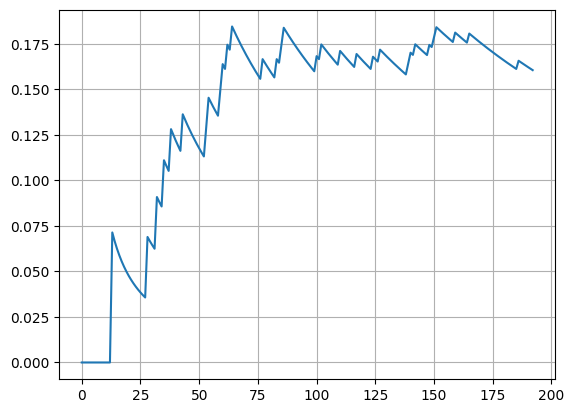

In [8]:
import matplotlib.pyplot as plt

count = 0
total_count = 0

rates = []

for s in range((len(stocks)-(len(stocks)-25))):
    
    code = stocks.iloc[s]['Code']
    name = stocks.iloc[s]['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    
    Q = 0
    
    for i in range(len(df) - 1):
    
        if df.iloc[i]['Close'] * 1.05 < df.iloc[i+1]['Close']:
            reward = 1
        else:
            reward = 0
        
        if Q > 0.9:
            if reward:
                count += 1
            total_count += 1
            rates.append(count / total_count)
            
        Q += (reward - Q) * 0.8
        
    if Q > 0.9:
        print(name)


plt.plot(rates)
plt.grid()
plt.show()